In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import datasets, transforms, models
import os
from PIL import Image

print('PyTorch version', torch.__version__)
print('Torchvision version', torchvision.__version__)

base_path = '/content/drive/MyDrive/Colab Notebooks/language-classifier/language-datasets'

PyTorch version 2.5.1+cu121
Torchvision version 0.20.1+cu121


In [2]:
import shutil

train_dir = 'train'
val_dir = 'validate'
test_dir = 'test'

# Cleanup step, remove existing train, validate, and test folders
for dataset_type in [train_dir, val_dir, test_dir]:
    dataset_path = os.path.join(base_path, dataset_type)
    if os.path.exists(dataset_path):
        shutil.rmtree(dataset_path)

In [3]:
import os
import shutil
from sklearn.model_selection import train_test_split

base_path = '/content/drive/MyDrive/Colab Notebooks/language-classifier/language-datasets'

# Create datasets: train, validate, and test
def split_dataset(base_path, train_dir='train', val_dir='validate', test_dir='test', val_pct=0.2, test_pct=0.1):
  # List all top-level folders ('progamming' and 'human')
  categories = ['human','programming']

  for category in categories:
    # Path to 'human' or 'programming'
    category_path = os.path.join(base_path, category)

    # List subfolders like 'english', 'python'
    subfolders = [
        sub for sub in os.listdir(category_path)
        if os.path.isdir(os.path.join(category_path, sub))
    ]

    for subfolder in subfolders:
      # Full path to subfolder
      subfolder_path = os.path.join(category_path, subfolder)
      images = [
          img for img in os.listdir(subfolder_path)
          if os.path.isfile(os.path.join(subfolder_path, img))
      ]

      # Filter out directories from the list of images
      # Skip subfolders that don't have enough images for splitting
      if len(images) < 3: # Adjust as needed based on minimum required images
        print(f"Skipping {subfolder_path} due to insufficient images.")
        continue


      # Split into training, validation, and test sets
      train_imgs, test_imgs = train_test_split(images, test_size=test_pct)
      train_imgs, val_imgs = train_test_split(train_imgs, test_size=val_pct)

      # Create directories if they don't exist
      for dataset_type, dataset_imgs in zip([train_dir, val_dir, test_dir], [train_imgs, val_imgs, test_imgs]):
        dataset_subfolder = os.path.join(base_path, dataset_type, subfolder)
        os.makedirs(dataset_subfolder, exist_ok=True)

        # Move files to respective folders
        for img in dataset_imgs:
          shutil.copy(
              os.path.join(subfolder_path, img),
              os.path.join(dataset_subfolder, img)
          )

# Run
split_dataset(base_path)

Skipping /content/drive/MyDrive/Colab Notebooks/language-classifier/language-datasets/programming/.ipynb_checkpoints due to insufficient images.


In [4]:
# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Standard normalization
])

# Create datasets
train_dataset = datasets.ImageFolder(os.path.join(base_path, 'train'), transform=transform)
val_dataset = datasets.ImageFolder(os.path.join(base_path, 'validate'), transform=transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)


In [5]:
# Extract class names
class_names = train_dataset.classes   # Returns a list of class names in alphabetical order
num_classes_in_dataset = len(train_dataset.classes)
print(f'Number of classes in dataset: {num_classes_in_dataset}')
print("Class Names:", class_names)
print("Amount in train and val datasets:", train_dataset.__len__(), val_dataset.__len__())

Number of classes in dataset: 4
Class Names: ['c++', 'english', 'japanese', 'python']
Amount in train and val datasets: 83 24


In [6]:
# Load pretrained ResNet18
model = models.resnet18(pretrained=True)

# Modify the final fully connected layer to match your number of classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes_in_dataset)

# Move the model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 127MB/s]


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 4

# Training loop to fine-tune the model
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')

Epoch 1/4, Loss: 1.6264
Epoch 2/4, Loss: 1.6812
Epoch 3/4, Loss: 0.9930
Epoch 4/4, Loss: 1.1608


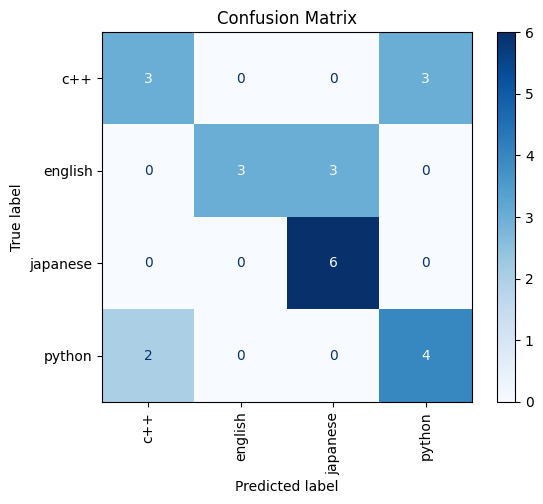

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Evaluate the model
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Get class names from dataset
class_names = list(train_dataset.class_to_idx.keys())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds, labels=range(len(class_names)))

# Plot Confusion Matrix with labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

Saving code-test-P.jpg to code-test-P.jpg
Prediction index: 3
Predicted class: 3


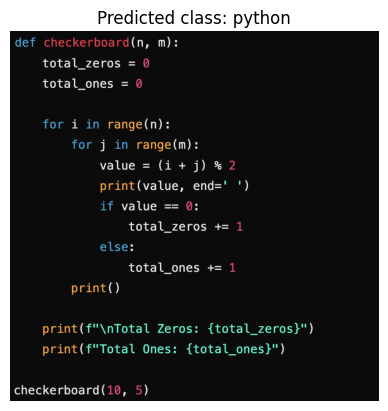

In [11]:
from google.colab import files

# Upload image
uploaded = files.upload() # Opens a prompt to upload image
img_path = list(uploaded.keys())[0]

def predict_image(img_path):
    # Load and preprocess the image
    img = Image.open(img_path)
    img = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img)
        _, predicted = torch.max(output, 1)

    return predicted.item()

# Make a prediction
pred_index = predict_image(img_path)
pred_class = train_dataset.classes[pred_index]
print(f'Prediction index: {pred_index}')
print(f'Predicted class: {pred_index}')

# Display image
img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')
plt.title(f'Predicted class: {pred_class}')
plt.show()